## SMS Scam Detection System: Naive Bayes & Semi-Supervised Learning

Description: Implements a custom Naive Bayes classifier from scratch to 
             detect malicious SMS messages.

Key Features: 

    1. Supervised Learning on labeled datasets.

    2. Semi-supervised self-training using high-confidence predictions.
    
    3. Performance evaluation via Confusion Matrices and F1 scoring.



## 1. Supervised model training


In [7]:
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split

# Set file paths for the datasets
training_set_path = "datasets/sms_supervised_train.csv"
test_set_path = "datasets/sms_test.csv"
unlabelled_set_path = "datasets/sms_unlabelled.csv"

# Read the datasets from CSV files
train_df = pd.read_csv(training_set_path)
test_df = pd.read_csv(test_set_path)
unlabelled_df = pd.read_csv(unlabelled_set_path)

# Remove rows with missing preprocessed text and reset index
train_df = train_df.dropna(subset=['textPreprocessed'])
train_df = train_df.reset_index(drop=True)
test_df = test_df.dropna(subset=['textPreprocessed'])
test_df = test_df.reset_index(drop=True)
unlabelled_df = unlabelled_df.dropna(subset=['textPreprocessed'])
unlabelled_df = unlabelled_df.reset_index(drop=True)

# Split the training dataframe into a training set and a validation set
train_set_df, val_set_df = train_test_split(train_df, test_size=0.3, random_state=42)
train_set_df = train_set_df.reset_index(drop=True)
val_set_df = val_set_df.reset_index(drop=True)

# Create the vocabulary from the preprocessed text
def define_vocabulary(data):
    vocabulary = set()
    for string in data['textPreprocessed']:
        vocabulary.update(string.split())
    return list(vocabulary)

# Create a count matrix of word frequencies for each message
def create_count_matrix(data, vocabulary):
    # Create a dictionary to map each word to an index
    vocab_index = {word: i for i, word in enumerate(vocabulary)}
    # Create a zero matrix with rows = messages, columns = vocabulary size
    count_matrix = np.zeros((len(data), len(vocabulary)), dtype=int)
    # Fill the matrix with counts of each word
    for index, row in data.iterrows():
        text = row['textPreprocessed'].split()
        for word in text:
            if word in vocab_index:
                count_matrix[index][vocab_index[word]] += 1
    return count_matrix, vocab_index

# Calculate prior probabilities for each class
def calc_priors(data):
    prior_probs = {}
    classes, counts = np.unique(data['class'], return_counts=True)
    n = counts.sum()
    for i in range(len(classes)):
        prior_probs[classes[i]] = counts[i] / n
    return prior_probs

# Calculate likelihoods for each word given a class using Laplace smoothing
def calc_likelihoods(data, count_matrix, vocabulary, alpha):
    likelihood = {}
    for cls in np.unique(data['class']):
        subset = data[data['class'] == cls]
        word_count = np.sum(count_matrix[subset.index], axis=0)
        total_words = np.sum(word_count)
        probabilities = (word_count + alpha) / (total_words + (alpha * len(vocabulary)))
        likelihood[cls] = probabilities
    return likelihood

# Calculate the posterior probabilities for a given message
def calc_posteriors(message, vocab_index, prior_probs, likelihood):
    count_vector = np.zeros(len(vocab_index))
    oov_count = 0 
    for word in message.split():
        if word in vocab_index: 
            count_vector[vocab_index[word]] += 1
        else:
            oov_count += 1
    # Return None if no known words are found
    if np.sum(count_vector) == 0:
        return None, oov_count
    posterior_probabilities = {}
    for cls in prior_probs:
        # Calculate log probability
        log_prob = np.log(prior_probs[cls])
        log_prob += np.sum(count_vector * np.log(likelihood[cls]))
        posterior_probabilities[cls] = log_prob
    return posterior_probabilities, oov_count

# Train the model: generate vocabulary, count matrix, priors, and likelihoods
def train_NB(data):
    vocabulary = define_vocabulary(data)
    count_matrix, vocab_index = create_count_matrix(data, vocabulary)
    prior_probs = calc_priors(data)
    likelihood = calc_likelihoods(data, count_matrix, vocabulary, 1)
    return vocabulary, vocab_index, prior_probs, likelihood

# Predict the class of each message using the trained Naïve Bayes model
def predict_NB(data, vocab_index, prior_probs, likelihood):
    classified_instances = []
    r_score_message = []
    oov_total = 0
    words_total = 0
    skipped_messages = 0
    for message in data['textPreprocessed']:
        posterior_probabilities, oov_count = calc_posteriors(message, vocab_index, prior_probs, likelihood)
        oov_total += oov_count
        words_total += len(message.split())
        if posterior_probabilities == None:
            classified_instances.append(None)
            skipped_messages += 1
            continue
        # Choose the class with the highest posterior probability
        predicted_class = max(posterior_probabilities, key=posterior_probabilities.get)
        classified_instances.append(predicted_class)
        # Calculate a ratio score for confidence measurement
        r_score_message.append(np.exp(posterior_probabilities[0] - posterior_probabilities[1]))
    return classified_instances, r_score_message

# Train the NB model on the training set
vocabulary_1, vocab_index_1, prior_probs_1, likelihood_1 = train_NB(train_set_df)

print("Prior probabilities:", prior_probs_1)
print()

# For each class, print the top 10 words with the highest likelihood
for cls in sorted(likelihood_1.keys()):
    probs = likelihood_1[cls]
    top_indices = np.argsort(probs)[-10:][::-1]  # Get indices of top 10 words
    print(f"Top 10 words for class {cls}:")
    for idx in top_indices:
        print(f"  {vocabulary_1[idx]}: {probs[idx]:.5f}")
    print()

# Calculate the ratio of likelihoods for non-malicious to scam words
r_score_words = likelihood_1[0] / likelihood_1[1]

# Print the top 10 words most predictive of the non-malicious class (high ratio)
top_non_words = np.argsort(r_score_words)[-10:][::-1]
print(f"Top {10} words most predictive of the non-malicious class:")
for idx in top_non_words:
    print(f"  {vocabulary_1[idx]}: Ratio = {r_score_words[idx]:.5f}")
print()

# Print the top 10 words most predictive of the scam class (low ratio)
top_scam_words = np.argsort(r_score_words)[:10]
print(f"Top {10} words most predictive of the scam class:")
for idx in top_scam_words:
    print(f"  {vocabulary_1[idx]}: Ratio = {r_score_words[idx]:.5f}")
print()




Prior probabilities: {np.int64(0): np.float64(0.7901146131805158), np.int64(1): np.float64(0.20988538681948424)}

Top 10 words for class 0:
  .: 0.07721
  ,: 0.02605
  ?: 0.02519
  ...: 0.01899
  u: 0.01860
  !: 0.01632
  ..: 0.01420
  go: 0.01114
  &: 0.01067
  ;: 0.01067

Top 10 words for class 1:
  .: 0.05123
  ,: 0.02288
  !: 0.02147
  call: 0.01951
  £: 0.01347
  free: 0.00940
  2: 0.00870
  /: 0.00856
  &: 0.00786
  ?: 0.00772

Top 10 words most predictive of the non-malicious class:
  ...: Ratio = 45.09965
  ;: Ratio = 38.01789
  :): Ratio = 38.01789
  ok: Ratio = 36.34063
  gt: Ratio = 34.10428
  lt: Ratio = 32.98611
  ü: Ratio = 22.92255
  lor: Ratio = 21.24529
  ask: Ratio = 19.00895
  k: Ratio = 16.77260

Top 10 words most predictive of the scam class:
  prize: Ratio = 0.01364
  £: Ratio = 0.01747
  award: Ratio = 0.02071
  claim: Ratio = 0.02150
  select: Ratio = 0.02541
  tone: Ratio = 0.02541
  customer: Ratio = 0.03050
  code: Ratio = 0.03289
  1000: Ratio = 0.03289
  en

## 2. Supervised model evaluation

In [8]:
# Evaluation function to compute and print metrics
def evaluation(true_labels, predictions):
    # Calculate accuracy
    accuracy = metrics.accuracy_score(true_labels, predictions)
    # Calculate confusion matrix with unique class labels from test_df
    confusion_matrix_result = metrics.confusion_matrix(true_labels, predictions, labels=np.unique(test_df['class']))
    # Calculate precision score
    precision = metrics.precision_score(true_labels, predictions)
    # Calculate recall score
    recall = metrics.recall_score(true_labels, predictions)
    # Calculate F1 score
    f1_score = metrics.f1_score(true_labels, predictions)

    # Print the evaluation metrics
    print("Accuracy:", accuracy)
    print("Confusion matrix:")
    print(confusion_matrix_result)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1_score)
    print()

# Get predictions and r-score messages from the= model on test data
predictions_1, r_score_message_1 = predict_NB(test_df, vocab_index_1, prior_probs_1, likelihood_1)
# Get the true labels from test_df as a list
true_labels = test_df['class'].tolist()

# Evaluate the model using the defined evaluation function
evaluation(true_labels, predictions_1)

# Initialize lists to store messages based on confidence scores
high_confidence_scam = []            # For messages highly confident as scam (low r-score)
high_confidence_non_malicious = []   # For messages highly confident as non-malicious (high r-score)
on_the_boundary = []                 # For messages with r-scores around the boundary (uncertain)

# Loop over each message's r-score in the test set
for i in range(len(r_score_message_1)):
    # If r-score is less than 0.1, it's a high confidence scam prediction
    if r_score_message_1[i] < 0.1:
        high_confidence_scam.append((test_df['textOriginal'][i], r_score_message_1[i]))
    # If r-score is between 0.9 and 1.1, the prediction is on the boundary (uncertain)
    elif (r_score_message_1[i] > 0.9) & (r_score_message_1[i] < 1.1):
        on_the_boundary.append((test_df['textOriginal'][i], r_score_message_1[i]))
    # If r-score is greater than 1.9, it's a high confidence non-malicious prediction
    elif r_score_message_1[i] > 1.9:
        high_confidence_non_malicious.append((test_df['textOriginal'][i], r_score_message_1[i]))


print(sorted(high_confidence_scam, key=lambda x: x[1], reverse=False)[:5])

print(sorted(high_confidence_non_malicious, key=lambda x: x[1], reverse=True)[:5])

print(sorted(on_the_boundary, key=lambda x: x[1], reverse=True)[:5])


Accuracy: 0.973
Confusion matrix:
[[784  16]
 [ 11 189]]
Precision: 0.9219512195121952
Recall: 0.945
F1 Score: 0.9333333333333333

[('CDs 4u: Congratulations ur awarded £500 of CD gift vouchers or £125 gift guaranteed & Freeentry 2 £100 wkly draw xt MUSIC to 87066 TnCs www.ldew.com1win150ppmx3age16', np.float64(2.960596480246975e-22)), ('You have WON a guaranteed £1000 cash or a £2000 prize. To claim yr prize call our customer service representative on 08714712394 between 10am-7pm', np.float64(3.0678877954796962e-21)), ('Todays Vodafone numbers ending 5347 are selected to receive a Rs.2,00,000 award. If you have a match please call 6299257179 quoting claim code 2041 standard rates apply', np.float64(1.8216866477090895e-20)), ('Todays Vodafone numbers ending 3156 are selected to receive a Rs.2,00,000 award. If you have a match please call 7908807538 quoting claim code 9823 standard rates apply', np.float64(2.42891553027887e-20)), ('Thanks for your ringtone order, reference number X49. Y

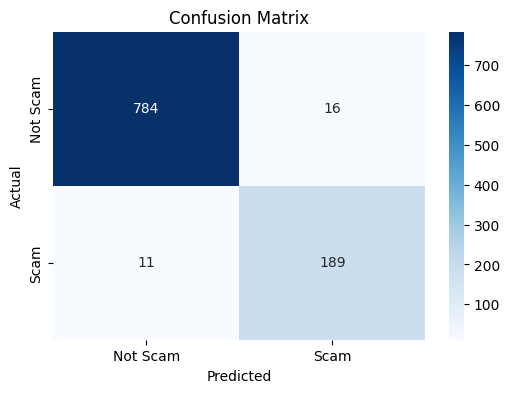

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm = metrics.confusion_matrix(true_labels, predictions_1, labels=np.unique(test_df['class']))

class_names = ['Not Scam', 'Scam']

# Create a heatmap picture of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



## 3. Extending the model with semi-supervised training

In [10]:

# Predict labels and confidence scores for the unlabelled data
predictions_2, r_score_message_2 = predict_NB(unlabelled_df, vocab_index_1, prior_probs_1, likelihood_1)

# Get the true labels from the validation set as a list
val_true_labels = val_set_df['class'].tolist()

# Copy the unlabelled data and attach the predicted classes
labelled_df = unlabelled_df.copy()
labelled_df['class'] = predictions_2

# Remove any rows where the prediction is missing (None)
labelled_df = labelled_df[labelled_df['class'].notna()].copy()

# Combine the original labelled training set with the newly labelled data
expanded_df = pd.concat([train_set_df, labelled_df])

# Train a new model on the expanded dataset
vocabulary_expanded, vocab_index_expanded, prior_probs_expanded, likelihood_expanded = train_NB(expanded_df)

# Use the expanded model to predict labels on the validation set
predictions_expanded, r_score_message_expanded = predict_NB(val_set_df, vocab_index_expanded, prior_probs_expanded, likelihood_expanded)

# Evaluate the performance of the expanded model using the validation set
evaluation(val_true_labels, predictions_expanded)



Accuracy: 0.9682804674457429
Confusion matrix:
[[482  10]
 [  9  98]]
Precision: 0.9074074074074074
Recall: 0.9158878504672897
F1 Score: 0.9116279069767442



## 3a. High Confidence Instances

In [11]:
def high_confidence_train(train_df, unlabelled_df, r_score_message, predictions, low, high):

    # Compute dynamic thresholds
    low_threshold = np.percentile(r_score_message, low)
    high_threshold = np.percentile(r_score_message, high)
    
    # Identify high confidence indices
    high_conf_indexes = [i for i, conf in enumerate(r_score_message) if conf < low_threshold or conf > high_threshold]
    
    # Extract high-confidence data
    high_conf_df = unlabelled_df.iloc[high_conf_indexes].copy()
    high_conf_df['class'] = [predictions[i] for i in high_conf_indexes]
    high_conf_df = high_conf_df[high_conf_df['class'].notna()].copy()  # Remove rows with None in class
    
    # Combine high confidence data with the initial training set
    high_confidence_df = pd.concat([train_df, high_conf_df], ignore_index=True)
    
    # Train model on the expanded dataset
    _, vocab_index_hc, prior_probs_hc, likelihood_hc = train_NB(high_confidence_df)

    return vocab_index_hc, prior_probs_hc, likelihood_hc


vocab_index_hc, prior_probs_hc, likelihood_hc = high_confidence_train(train_set_df, unlabelled_df, r_score_message_2, predictions_2, 10, 90)

predictions_hc, r_score_message_hc = predict_NB(val_set_df, vocab_index_hc, prior_probs_hc, likelihood_hc)

evaluation_results = evaluation(val_true_labels, predictions_hc)

Accuracy: 0.9699499165275459
Confusion matrix:
[[479  13]
 [  5 102]]
Precision: 0.8869565217391304
Recall: 0.9532710280373832
F1 Score: 0.918918918918919



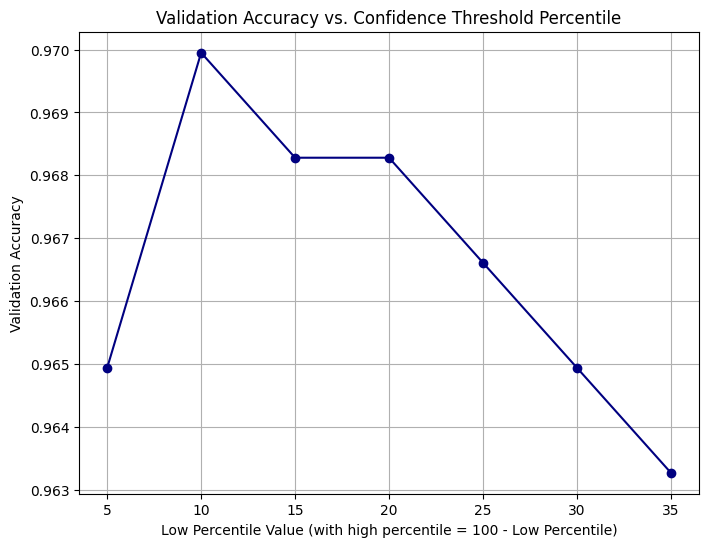

In [12]:
threshold_low_values = list(range(5, 36, 5))
accuracies = []

for low_pct in threshold_low_values:
    high_pct = 100 - low_pct  
    # Train with high-confidence data obtained from the given thresholds
    vocab_index_hc, prior_probs_hc, likelihood_hc = high_confidence_train(
        train_set_df, unlabelled_df, r_score_message_2, predictions_2, low_pct, high_pct)
    
    # Predict on the validation set
    predictions_val, _ = predict_NB(val_set_df, vocab_index_hc, prior_probs_hc, likelihood_hc)
    
    # Compute accuracy on the validation set
    acc = metrics.accuracy_score(val_true_labels, predictions_val)
    accuracies.append(acc)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(threshold_low_values, accuracies, marker='o', linestyle='-', color='navy')
plt.xlabel('Low Percentile Value (with high percentile = 100 - Low Percentile)')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. Confidence Threshold Percentile')
plt.grid(True)
plt.show()


## 3b. Iterative Update (halve each iteration)

In [13]:
def iterative_half_train(train_df, unlabelled_df, fraction):
    
    updated_train = train_df.copy()
 
    remaining_unlabelled = unlabelled_df.copy()

    iteration = 0 
    while not remaining_unlabelled.empty:  # Loop until there is no unlabelled data left
        iteration += 1

        # Sample a fraction of the remaining unlabelled data
        sampled_index = remaining_unlabelled.sample(frac=fraction, random_state=42).index
        sample_data = remaining_unlabelled.loc[sampled_index].copy()

        # Train the model on the current training set
        _, vocab_index_curr, prior_probs_curr, likelihood_curr = train_NB(updated_train)

        # Predict labels for the sampled unlabelled data using the current model
        preds, _ = predict_NB(sample_data, vocab_index_curr, prior_probs_curr, likelihood_curr)

  
        sample_data['class'] = preds
     
        sample_data = sample_data[sample_data['class'].notna()].copy()

        # Update the training set by appending the newly labelled data
        updated_train = pd.concat([updated_train, sample_data], ignore_index=True)

        # Remove the sampled data from the remaining unlabelled data
        remaining_unlabelled = remaining_unlabelled.drop(sampled_index)

        if len(remaining_unlabelled) < 10:
            break

    _, vocab_index_halve, prior_probs_halve, likelihood_halve = train_NB(updated_train)

    return vocab_index_halve, prior_probs_halve, likelihood_halve


vocab_index_halve, prior_probs_halve, likelihood_halve = iterative_half_train(train_set_df, unlabelled_df, 0.6)

predictions_halve, r_score_message_halve = predict_NB(val_set_df, vocab_index_halve, prior_probs_halve, likelihood_halve)


evaluation(val_true_labels, predictions_halve)

Accuracy: 0.9649415692821369
Confusion matrix:
[[476  16]
 [  5 102]]
Precision: 0.864406779661017
Recall: 0.9532710280373832
F1 Score: 0.9066666666666666



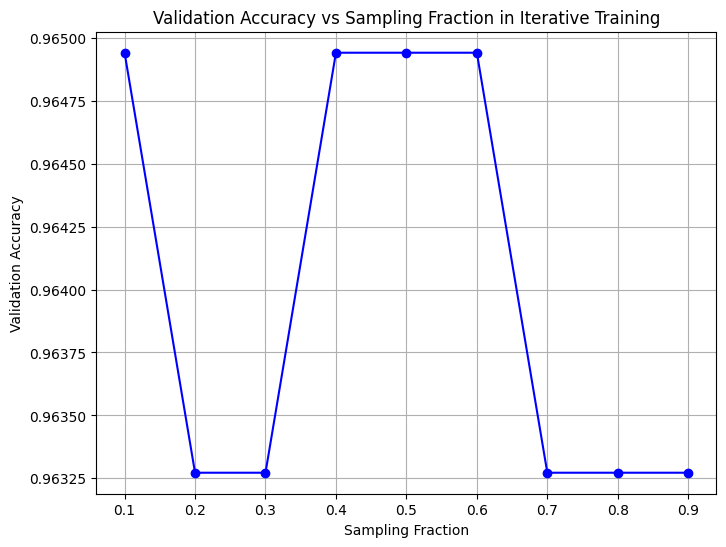

In [14]:
fraction_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
accuracy_list = []

# Loop over each sampling fraction.
for frac in fraction_values:
    # Iterative half-training process with the current fraction.
    vocab_index_fr, prior_probs_fr, likelihood_fr = iterative_half_train(train_set_df, unlabelled_df, frac)
    
    # Predict on the validation set.
    predictions_fr, _ = predict_NB(val_set_df, vocab_index_fr, prior_probs_fr, likelihood_fr)
    
    # Compute the accuracy based on validation true labels.
    acc = metrics.accuracy_score(val_true_labels, predictions_fr)
    accuracy_list.append(acc)
    

# Plot the validation accuracy against the sampling fraction.
plt.figure(figsize=(8, 6))
plt.plot(fraction_values, accuracy_list, marker='o', linestyle='-', color='blue')
plt.xlabel("Sampling Fraction")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Sampling Fraction in Iterative Training")
plt.grid(True)
plt.show()

## 3c. Iterative Update (even splits)

In [15]:
def even_iterative_train(train_df, unlabelled_df, iterations):

    updated_train = train_df.copy()
    remaining_unlabelled = unlabelled_df.copy()

    # Calculate the size of each split based on the number of iterations
    split_size = len(remaining_unlabelled) // iterations

    # Iterate a fixed number of times (iterations)
    for i in range(iterations):
        # Sample a split (chunk) of unlabelled data of size split_size
        split_index = remaining_unlabelled.sample(n=split_size, random_state=42).index
        split_data = remaining_unlabelled.loc[split_index].copy()

        # Train a model on the current updated training set
        _, vocab_index_curr, prior_probs_curr, likelihood_curr = train_NB(updated_train)

   
        preds, _ = predict_NB(split_data, vocab_index_curr, prior_probs_curr, likelihood_curr)

        # Assign the predicted class labels to the sampled data
        split_data['class'] = preds
        # Filter out any rows where the prediction is missing (None)
        split_data = split_data[split_data['class'].notna()].copy()

        # Append the newly labelled data to the existing training set
        updated_train = pd.concat([updated_train, split_data], ignore_index=True)

        # Remove the processed split from the unlabelled dataset by dropping the first split_size rows
        remaining_unlabelled = remaining_unlabelled[split_size:]

    # Retrain the model on the fully updated training set after all iterations
    _, vocab_index_even, prior_probs_even, likelihood_even = train_NB(updated_train)


    return vocab_index_even, prior_probs_even, likelihood_even


vocab_index_even, prior_probs_even, likelihood_even = even_iterative_train(train_set_df, unlabelled_df, iterations=4)


predictions_even, r_score_message_even = predict_NB(val_set_df, vocab_index_even, prior_probs_even, likelihood_even)


evaluation(val_true_labels, predictions_even)


Accuracy: 0.9666110183639399
Confusion matrix:
[[476  16]
 [  4 103]]
Precision: 0.865546218487395
Recall: 0.9626168224299065
F1 Score: 0.911504424778761



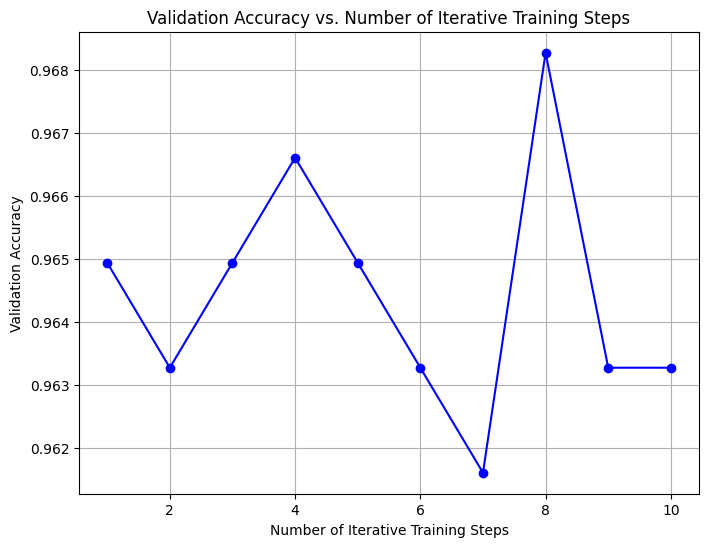

In [16]:
# Number of iteration steps you want to test.
iteration_counts = range(1, 11)
accuracies = []

# Loop over the different iteration values
for iters in iteration_counts:
    # Train the model iteratively
    vocab_index_iter, prior_probs_iter, likelihood_iter = even_iterative_train(
        train_df=train_set_df, 
        unlabelled_df=unlabelled_df, 
        iterations=iters
    )
    
    # Predict on the validation set using the trained model
    predictions_iter, _ = predict_NB(val_set_df, vocab_index_iter, prior_probs_iter, likelihood_iter)
    
    # Compute accuracy on the validation set
    acc = metrics.accuracy_score(val_true_labels, predictions_iter)
    accuracies.append(acc)

# Plot the relationship between iteration count and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(list(iteration_counts), accuracies, marker='o', linestyle='-', color='blue')
plt.xlabel("Number of Iterative Training Steps")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs. Number of Iterative Training Steps")
plt.grid(True)
plt.show()

## 3d. Iterative Update + High Confidence

In [17]:
def iterative_high_conf_train(train_df, unlabelled_df):

    updated_train = train_df.copy()
    remaining_unlabelled = unlabelled_df.copy()

    iteration = 0 

    # Continue while there is still unlabelled data left
    while not remaining_unlabelled.empty:
        iteration += 1  

        # Sample 60% of the remaining unlabelled data
        sampled_index = remaining_unlabelled.sample(frac=0.6, random_state=42).index
        sample_data = remaining_unlabelled.loc[sampled_index].copy()

        # Train a Naïve Bayes model on the current updated training set
        _, vocab_index_curr, prior_probs_curr, likelihood_curr = train_NB(updated_train)

        # Use the trained model to predict labels and get confidence scores for the sample
        predictions, r_scores = predict_NB(sample_data, vocab_index_curr, prior_probs_curr, likelihood_curr)

        # Attach the predicted labels to the sample data
        sample_data['class'] = predictions

        # Calculate dynamic thresholds based on the 10th and 90th percentiles ofconfidence scores
        low_threshold = np.percentile(r_scores, 10)
        high_threshold = np.percentile(r_scores, 90)

        # Identify indices for high confidence predictions: either very low or very high r-scores
        high_conf_indexes = [i for i, conf in enumerate(r_scores) if conf < low_threshold or conf > high_threshold]

        # Extract the high-confidence samples from the rated sample
        high_conf_sample = sample_data.iloc[high_conf_indexes].copy()
        # Reinforce the class labels for these samples using the corresponding predictions
        high_conf_sample['class'] = [predictions[i] for i in high_conf_indexes]
        # Remove any rows with missing predictions
        high_conf_sample = high_conf_sample[high_conf_sample['class'].notna()].copy()

        # Add the high-confidence labelled samples to the updated training set
        updated_train = pd.concat([updated_train, high_conf_sample], ignore_index=True)

        # Remove the entire sampled split from the remaining unlabelled data
        remaining_unlabelled = remaining_unlabelled.drop(sampled_index)

        # Break the loop if there are fewer than 10 unlabelled examples left
        if len(remaining_unlabelled) < 10:
            break

    # After labelling, retrain the model on the fully updated training data
    _, vocab_index_final, prior_probs_final, likelihood_final = train_NB(updated_train)

    # Return the updated model parameters
    return vocab_index_final, prior_probs_final, likelihood_final

# Execute the iterative high-confidence training using the train_set_df and unlabelled_df
vocab_index_final, prior_probs_final, likelihood_final = iterative_high_conf_train(train_set_df, unlabelled_df)

# Predict the labels on the validation set using the final updated model
predictions_final, r_score_message_final = predict_NB(val_set_df, vocab_index_final, prior_probs_final, likelihood_final)

# Evaluate the model performance on the validation set
evaluation(val_true_labels, predictions_final)


Accuracy: 0.9616026711185309
Confusion matrix:
[[475  17]
 [  6 101]]
Precision: 0.8559322033898306
Recall: 0.9439252336448598
F1 Score: 0.8977777777777778



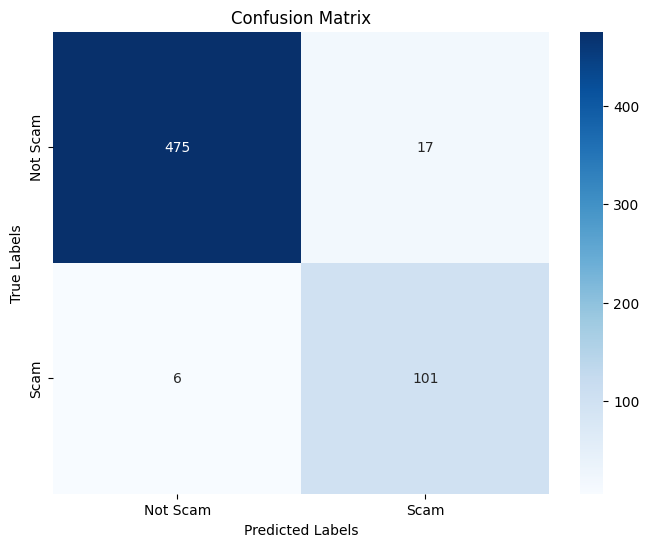

In [18]:
cm = metrics.confusion_matrix(val_true_labels, predictions_final)


class_labels = ['Not Scam', 'Scam']  # Example for binary classification

# Plot the confusion matrix using Seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix')
plt.show()


## 4. Supervised model evaluation

In [19]:

#SHow evaluation metrics

print('Expanded:')
predictions_2, r_score_message_2 = predict_NB(unlabelled_df, vocab_index_1, prior_probs_1, likelihood_1)
labelled_df = unlabelled_df.copy()
labelled_df['class'] = predictions_2
labelled_df = labelled_df[labelled_df['class'].notna()].copy()
expanded_df = pd.concat([train_df, labelled_df])
vocabulary_expanded, vocab_index_expanded, prior_probs_expanded, likelihood_expanded = train_NB(expanded_df)
predictions_expanded, r_score_message_expanded = predict_NB(test_df, vocab_index_expanded, prior_probs_expanded, likelihood_expanded)
evaluation(true_labels, predictions_expanded)

print('High Confidence:')
vocab_index_hc, prior_probs_hc, likelihood_hc = high_confidence_train(train_df, unlabelled_df, r_score_message_2, predictions_2, 10, 90)
predictions_hc, r_score_message_hc = predict_NB(test_df, vocab_index_hc, prior_probs_hc, likelihood_hc)
evaluation_results = evaluation(true_labels, predictions_hc)

print('Iterative Fraction:')
vocab_index_halve, prior_probs_halve, likelihood_halve = iterative_half_train(train_df, unlabelled_df, 0.6)
predictions_halve, r_score_message_halve = predict_NB(test_df, vocab_index_halve, prior_probs_halve, likelihood_halve)
evaluation(true_labels, predictions_halve)

print('Iterative Even Splits:')
vocab_index_even, prior_probs_even, likelihood_even = even_iterative_train(train_df, unlabelled_df, iterations=8)
predictions_even, r_score_message_even = predict_NB(test_df, vocab_index_even, prior_probs_even, likelihood_even)
evaluation(true_labels, predictions_even)

print('Iterative Fraction + High Confidence')
vocab_index_final, prior_probs_final, likelihood_final = iterative_high_conf_train(train_df, unlabelled_df)
predictions_final, r_score_message_final = predict_NB(test_df, vocab_index_final, prior_probs_final, likelihood_final)
evaluation(true_labels, predictions_final)

Expanded:
Accuracy: 0.98
Confusion matrix:
[[793   7]
 [ 13 187]]
Precision: 0.9639175257731959
Recall: 0.935
F1 Score: 0.949238578680203

High Confidence:
Accuracy: 0.976
Confusion matrix:
[[786  14]
 [ 10 190]]
Precision: 0.9313725490196079
Recall: 0.95
F1 Score: 0.9405940594059405

Iterative Fraction:
Accuracy: 0.978
Confusion matrix:
[[788  12]
 [ 10 190]]
Precision: 0.9405940594059405
Recall: 0.95
F1 Score: 0.945273631840796

Iterative Even Splits:
Accuracy: 0.971
Confusion matrix:
[[781  19]
 [ 10 190]]
Precision: 0.9090909090909091
Recall: 0.95
F1 Score: 0.9290953545232273

Iterative Fraction + High Confidence
Accuracy: 0.971
Confusion matrix:
[[782  18]
 [ 11 189]]
Precision: 0.9130434782608695
Recall: 0.945
F1 Score: 0.9287469287469288



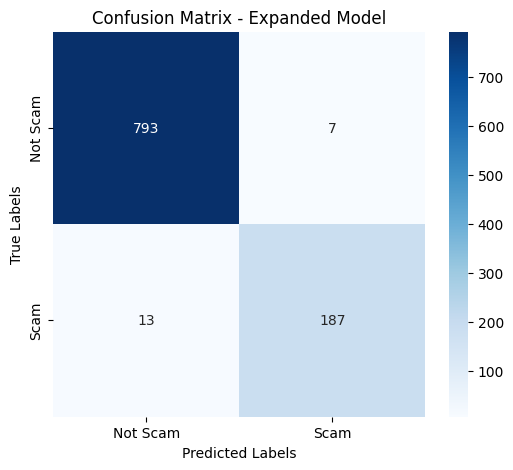

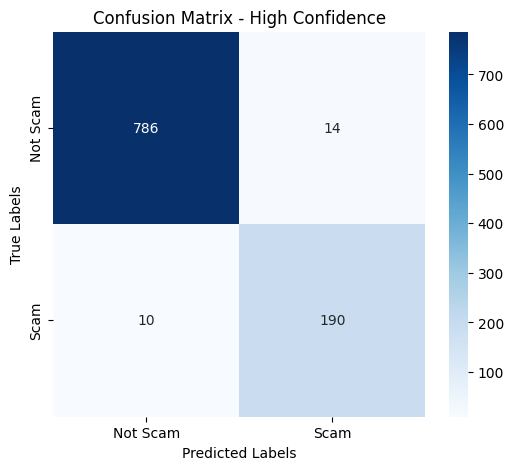

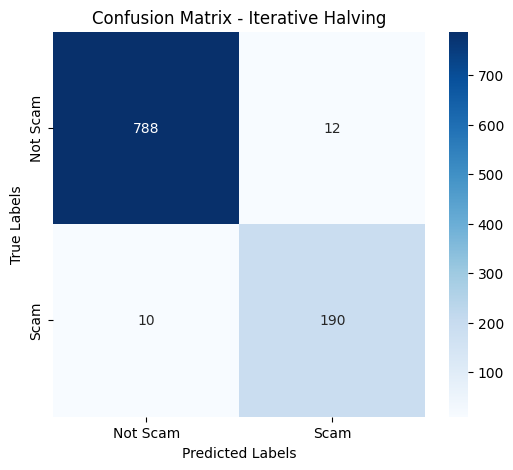

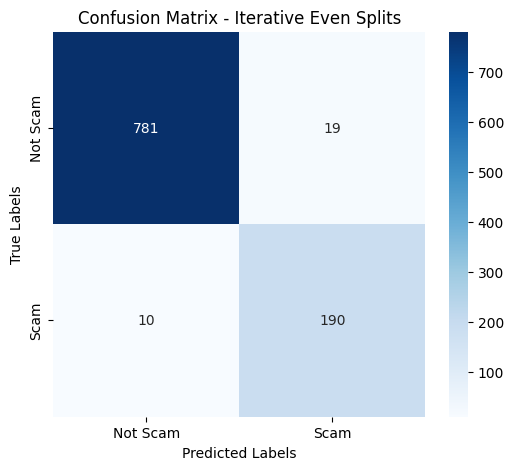

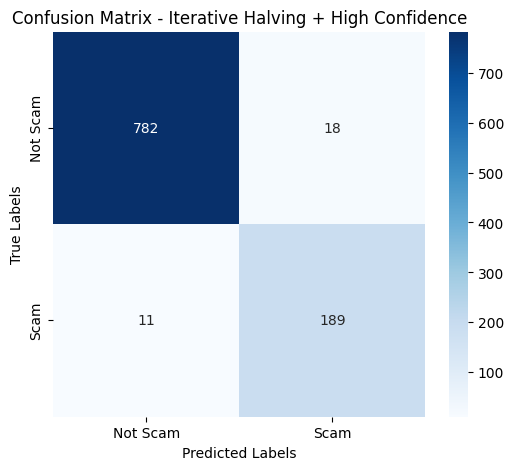

In [20]:
# Define class labels (change as per your dataset)
class_labels = ['Not Scam', 'Scam']

# Expanded Model
cm_expanded = metrics.confusion_matrix(true_labels, predictions_expanded)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_expanded, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Expanded Model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# High Confidence Model
cm_hc = metrics.confusion_matrix(true_labels, predictions_hc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - High Confidence")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Iterative Halving
cm_halve = metrics.confusion_matrix(true_labels, predictions_halve)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_halve, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Iterative Halving")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Iterative Even Splits
cm_even = metrics.confusion_matrix(true_labels, predictions_even)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_even, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Iterative Even Splits")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#Iterative Halving + High Confidenc
cm_final = metrics.confusion_matrix(true_labels, predictions_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Iterative Halving + High Confidence")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()